# UC San Diego: Neural Data Science
## Generative AI and Cognitive Function in College Students
 

## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ X ] YES - make available
* [  ] NO - keep private

## Names
- Aidan Ho
- Ranya Tashkandy
- Nasrin Omar

## Overview

In this project, we compare self-reported cognitive-function measures from two college datasets collected before and after the widespread adoption of generative AI. Because the datasets used different survey instruments and scoring scales, composite cognitive-function scores were standardized using z-score normalization to facilitate comparison. We specifically examine whether students surveyed after the widespread adoption of generative AI exhibit lower standardized cognitive-function measures than students surveyed before its adoption. Using data visualizations and statistical analysis, we compare the distributions of standardized cognitive-function measures between pre-AI and post-AI cohorts. Our goal is not to determine whether AI directly causes cognitive changes, but rather to examine whether measurable differences exist between students surveyed before and after the widespread adoption of generative AI. 

<a id='research_question'></a>
## Research Question

How do self-reported cognitive-function scores differ between college student cohorts sampled before (2018–2019) and after (2023–2025) the widespread adoption of generative AI?

**Variables:**
- **Grouping variable:** AI era — Pre-AI (RU Mindful, 2018–2019) vs. Post-AI (UEF-1, 2024)
- **Primary Outcome** Variable: Standardized cognitive-function score (z-score) 
- **Pre-AI proxy:** Average of `CognitiveAbilities` and `CognitiveFunctioning` T-scores (RU Mindful)
- **Post-AI proxy:** Grand mean of 7 validated executive function subscale totals (UEF-1)

<a id='background'></a>

## Background & Prior Work

Artificial intelligence tools have revolutionized the way we learn and create in our world, allowing students to finish homework, create art, and answer difficult questions in a matter of seconds. For many students, tools like AI have already become normal, making information faster and easier to access than ever before. But is the reliance that all these students seem to have on AI as innocent as it seems?

Research has raised concerns about the overdependence on tools like AI, believing that some students rely on AI instead of thinking through problems on their own. This idea is known as “cognitive offloading,” where technology performs thinking tasks that people previously would have done on their own (Risko & Gilbert, 2016). Risko and Gilbert found that while offloading tasks to external tools can boost immediate performance, it simultaneously reduces memory encoding and independent recall over time. These effects may influence attention, learning habits, and independent problem-solving abilities, potentially contributing to reduced deep focus and increased reliance on immediate answers.
This topic is particularly important because millions of students now have AI embedded in their studying and learning routines. Georgiou (2025) conducted a controlled experiment where 40 students completed an argumentative writing task either with or without ChatGPT assistance, and found that students who used ChatGPT scored significantly lower on cognitive engagement, including less deep processing, less mental effort, weaker sustained attention, and less strategic thinking than students who worked independently. Similarly, Aruon, Shealy, and Gero (2025) used functional near-infrared spectroscopy to examine brain activity in undergraduate students completing design tasks with and without generative AI assistance. They found that students using AI exhibited lower activation in the prefrontal cortex, a brain region associated with executive functioning and higher-order reasoning, and that this reduction persisted even during later tasks when AI was no longer available.

While previous studies have examined the effects of AI-assisted task completion on cognitive engagement and executive functioning, there is limited population-level evidence comparing cognitive-function measures across student cohorts before and after the widespread adoption of generative AI.

**References:**
- Aruon, A., Shealy, T., & Gero, J. (2025). An empirical study measuring the effects of generative AI on early-stage engineering design and neurocognition. *Proceedings of the ASME 2025 IDETC-CIE*, DETC2025-169255. https://par.nsf.gov/servlets/purl/10644925
- Georgiou, G. P. (2025). ChatGPT produces more 'lazy' thinkers: Evidence of cognitive engagement decline. *arXiv*. https://arxiv.org/pdf/2507.00181
- Klarin, A., Hoff, E., Larsson, T., & Daukantaitė, D. (2024). Adolescents' use and perceived usefulness of generative AI for schoolwork: Exploring relationships with executive functioning and academic achievement. *Frontiers in Artificial Intelligence, 7*. https://doi.org/10.3389/frai.2024.1415782
- Risko, E. F., & Gilbert, S. J. (2016). Cognitive offloading. *Trends in Cognitive Sciences, 20*(9), 676–688. https://doi.org/10.1016/j.tics.2016.07.002

## Hypothesis


We hypothesize that college students sampled after the widespread adoption of generative AI will report lower standardized cognitive-functioning scores than students sampled before its adoption. As generative AI becomes more integrated into students’ academic routines, greater reliance on these tools may be associated with lower self-reported cognitive functioning. If students increasingly outsource effortful thinking to AI, we would expect measurable reductions in the prefrontal-cortex-dependent behaviors.


## Dataset(s)

**Dataset 1 — RU Mindful (Pre-AI baseline)**
- **Link:** https://rdw.rowan.edu/datasets/2/
- **N:** 534 college students
- **Collection period:** April 2018 – September 2019 (prior to ChatGPT's November 2022 launch)
- **Collection method:** Online self-report survey administered to undergraduate students at Rowan University, New Jersey
- **Key variables used:** `CognitiveAbilities` and `CognitiveFunctioning` (both T-scores from a validated cognitive battery, mean ~50, SD ~10), `GPA`, perceived stress (PSS), and mindfulness (CAMSR)
- **Our EF proxy:** Average of `CognitiveAbilities` and `CognitiveFunctioning`

**Dataset 2 — UEF-1 (Post-AI comparison)**
- **Link:** https://data.mendeley.com/datasets/gfrmzgmkbt/2
- **N:** 1,373 university students
- **Collection period:** 2024 (after generative AI's mass adoption)
- **Collection method:** Self-report survey administered to students at universities in Chile and Ecuador, using the validated UEF-1 executive function instrument 
- **Key variables used:** 7 pre-computed subscale totals — Conscious Monitoring of Responsibilities, Supervisory Attentional System, Emotional Regulation, Behavior Verification, Decision Making, Inhibitory Control, and Task Organization — each scored as raw totals on different scales
- **Our EF proxy:** Grand mean of all 7 subscale totals, providing a single validated EF composite

**How we combine these datasets:** Because the two instruments use completely different scoring scales, raw scores cannot be directly compared. We z-score normalize each dataset's EF composite independently, before stacking them into a single comparison dataframe. This allows us to compare the relative position of each student within their own cohort's distribution.

| Dataset | Source | Era | N |
|---|---|---|---|
| RU Mindful | [rdw.rowan.edu/datasets/2](https://rdw.rowan.edu/datasets/2/) | Pre-AI (2018–2019) | 534 |
| UEF-1 | [data.mendeley.com/datasets/gfrmzgmkbt/2](https://data.mendeley.com/datasets/gfrmzgmkbt/2) | Post-AI (2024) | 1,373 |

## Data Wrangling

* Explain steps taken to pull the data you need into Python.

In [1]:
pip install pandas numpy scipy matplotlib seaborn openpyxl requests


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import requests
import io

from scipy.stats import zscore, ttest_ind, mannwhitneyu

import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
# Pre-AI (Rowan dataset)
RU_URL = "https://rdw.rowan.edu/context/datasets/article/1002/type/native/viewcontent"

ru_raw = pd.read_excel(
    io.BytesIO(requests.get(RU_URL, timeout=60).content),
    engine="openpyxl"
)

# Post-AI dataset
uef_raw = pd.read_excel(
    "UEF_dataset.xlsx",
    engine="openpyxl"
)


In [4]:
print("Pre-AI shape:", ru_raw.shape)
print("Post-AI shape:", uef_raw.shape)


Pre-AI shape: (534, 16)
Post-AI shape: (1373, 42)


## Data Cleaning
To make the datasets easier to work with, column names were standardized by converting them to lowercase and removing spaces and special
characters. This prevents attribute access errors and ensures consistent column naming across both datasets before any merging or comparison.

In [5]:
def clean_cols(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[\s\-/]+", "_", regex=True)
        .str.replace(r"[^\w]", "", regex=True)
    )
    return df

ru = clean_cols(ru_raw.copy())
uef = clean_cols(uef_raw.copy())


## Constructing Comparable Cognitive Function Measures

The two datasets use different survey instruments and different scoring scales, so a direct numerical comparison of raw scores is not valid. To create a single comparable measure from each dataset, we construct a composite cognitive-function score for each student.

In [6]:
# PRE-AI: average of two T-score cognitive measures

ru["cognitiveabilities"] = pd.to_numeric(ru["cognitiveabilities"], errors="coerce")
ru["cognitivefunctioning"] = pd.to_numeric(ru["cognitivefunctioning"], errors="coerce")
ru["cog_score"] = ru[["cognitiveabilities", "cognitivefunctioning"]].mean(axis=1)

pre = ru["cog_score"].dropna()

# POST-AI: executive function score


subscales = [
    "monitorizacionconscieteresponsabilidades",
    "sistemaatencionalsupervisor",
    "regulaciondeliberadaemocion",
    "verificaciondelaconducta",
    "tomadedecisiones",
    "controlinhibitorio",
    "organizacionelemnetostareas"
]

# rename safely to avoid long names
uef_rename = {c: f"f{i}" for i, c in enumerate(subscales, 1)}
uef = uef.rename(columns=uef_rename)
subscales_clean = list(uef_rename.values())

for col in subscales_clean:
    uef[col] = pd.to_numeric(uef[col], errors="coerce")

uef["cog_score"] = uef[subscales_clean].mean(axis=1)
post = uef["cog_score"].dropna()


print(f"Pre-AI  (RU Mindful): N={len(pre)}, mean={pre.mean():.2f}, SD={pre.std():.2f}")
print(f"Post-AI (UEF-1):      N={len(post)}, mean={post.mean():.2f}, SD={post.std():.2f}")






Pre-AI  (RU Mindful): N=534, mean=47.75, SD=7.30
Post-AI (UEF-1):      N=1373, mean=24.14, SD=2.72


## Z-Score Normalization

For this section we normalized Z-score for each dataset, this is necessary because the RU Mindful T-scores range roughly from 27–66, while the UEF-1 subscale mean ranges from roughly 10–40. Without normalization, any numerical comparison would reflect scale differences rather than true distributional differences. After z-scoring, each student's score represents their position relative to their own cohort — allowing us to compare distributions across the two groups properly.

In [7]:
# Z-score each group independently
pre_z = zscore(pre)
post_z = zscore(post)

# combined

df = pd.concat([
    pd.DataFrame({"era": "pre_AI", "cog_score": pre}),
    pd.DataFrame({"era": "post_AI", "cog_score": post})
])


In [8]:
df = pd.concat([
    pd.DataFrame({
        "era": "Pre-AI",
        "score": pre_z
}),
pd.DataFrame({
    "era": "Post-AI",
    "score": post_z
})
])
df.head()


,era,score
0,Pre-AI,1.521220
1,Pre-AI,-1.220249
2,Pre-AI,0.678218
3,Pre-AI,0.643950
4,Pre-AI,1.665147


In [9]:
df["era"].value_counts()


era
Post-AI    1373
Pre-AI      534
Name: count, dtype: int64

## Descriptive Statistics
The following table summarizes the distributions of standardized cognitive-function scores.

In [10]:
df.groupby("era")["score"].agg([
"count",
"mean",
"median",
"std",
"min",
"max"
])


,count,mean,median,std,min,max
era,,,,,,
Post-AI,1373,1.465850e-15,0.105085,1.000364,-3.153736,2.154989
Pre-AI,534,9.936392e-16,-0.072259,1.000938,-2.954228,2.323100


## Distribution of Standardized Cognitive Function Scores

To compare the overall distributions of cognitive-function scores between the two cohorts, we visualize kernel density estimates (KDEs) of the
standardized scores. This allows us to compare the shape, spread, and central tendency of each distribution.* This is a good place for some relevant visualizations related to any exploratory data anlayses (EDA) you did after the basic cleaning.

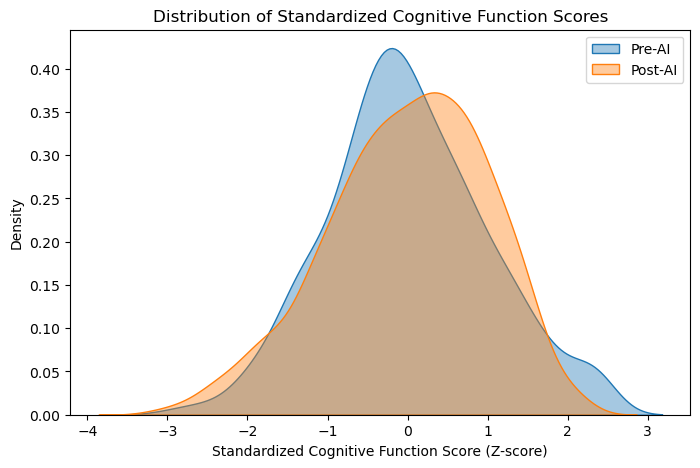

In [11]:
plt.figure(figsize=(8,5))
sns.kdeplot(
    pre_z,
    label="Pre-AI",
    fill=True,
    alpha=0.4
)
sns.kdeplot(
    post_z,
    label="Post-AI",
    fill=True,
    alpha=0.4
)
plt.title("Distribution of Standardized Cognitive Function Scores")
plt.xlabel("Standardized Cognitive Function Score (Z-score)")
plt.ylabel("Density")
plt.legend()
plt.show()


**Interpretation:** Both distributions are approximately normal and centered near zero. The curves overlap substantially, suggesting that the two cohorts are similarly distributed on their respective cognitive-function measures. The degree of overlap here provides an early visual indication that any between-group difference is likely small.

## Boxplot Comparison

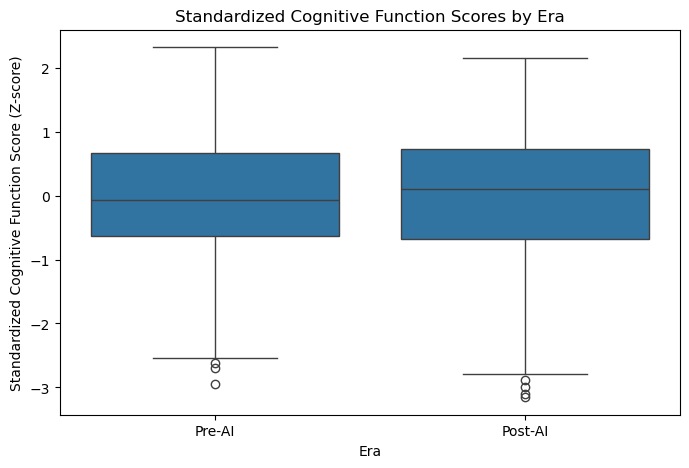

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="era",
    y="score"
)
plt.title("Standardized Cognitive Function Scores by Era")
plt.xlabel("Era")
plt.ylabel("Standardized Cognitive Function Score (Z-score)")
plt.show()


**Interpretation:** The boxplot displays the median, interquartile range (box), and outliers for each cohort. Both groups show a median near zero and similar IQR spread, reinforcing what the KDE plot suggested — the two distributions are closely matched. Neither box is meaningfully shifted above or below this line, which is consistent with a null result: there is no visible difference in the spread of cognitive-function scores between the pre-AI and post-AI datasets.

## Violin Plot Comparison
A violin plot combines features of a boxplot and density plot. It allows us to examine both summary statistics and the underlying distribution of scores
within each cohort.

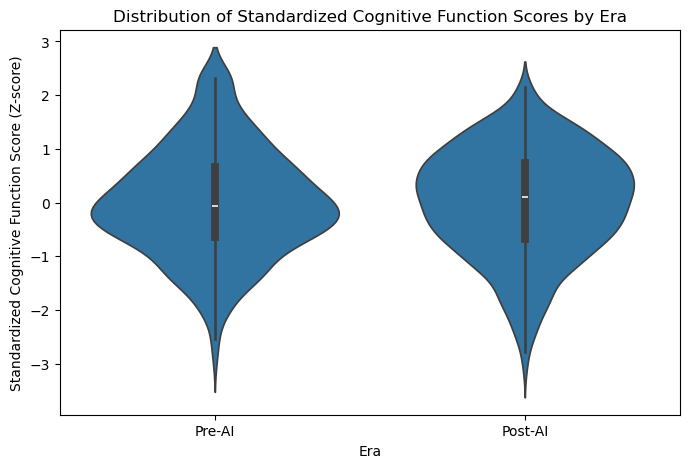

In [13]:
plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x="era",
    y="score",
    inner="box"
)
plt.title("Distribution of Standardized Cognitive Function Scores by Era")
plt.xlabel("Era")
plt.ylabel("Standardized Cognitive Function Score (Z-score)")
plt.show()


## Histogram of Cognitive Function Scores

This histogram shows that the Pre-AI and Post-AI cohorts have largely overlapping cognitive-function score distributions, indicating similar overall performance patterns.


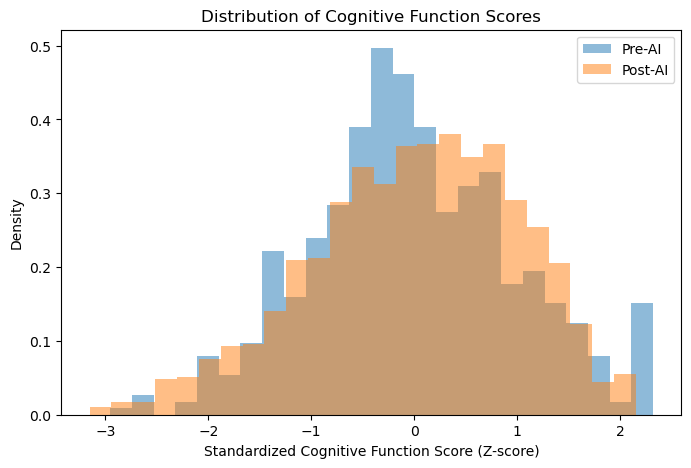

In [14]:
plt.figure(figsize=(8,5))

plt.hist(pre_z, bins=25, alpha=0.5, label="Pre-AI", density=True)
plt.hist(post_z, bins=25, alpha=0.5, label="Post-AI", density=True)

plt.xlabel("Standardized Cognitive Function Score (Z-score)")
plt.ylabel("Density")
plt.title("Distribution of Cognitive Function Scores")
plt.legend()

plt.show()


## Cumulative Distribution of Cognitive Function Scores

This plot compares the cumulative distributions of cognitive-function scores for the Pre-AI and Post-AI cohorts, showing that the two groups have broadly similar score patterns.



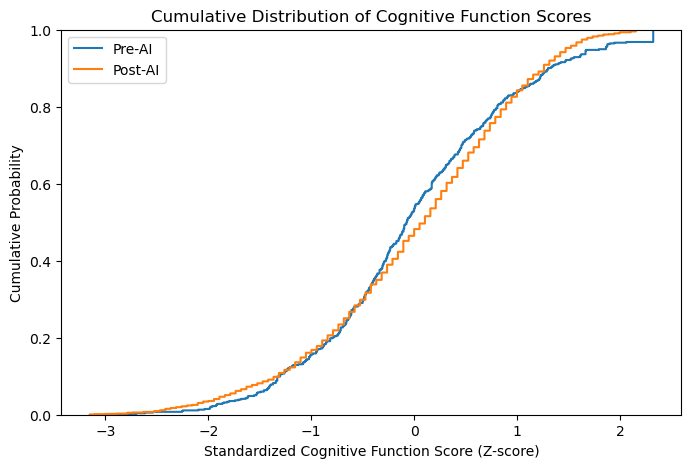

In [15]:

plt.figure(figsize=(8,5))

sns.ecdfplot(pre_z, label="Pre-AI")
sns.ecdfplot(post_z, label="Post-AI")

plt.xlabel("Standardized Cognitive Function Score (Z-score)")
plt.ylabel("Cumulative Probability")
plt.title("Cumulative Distribution of Cognitive Function Scores")
plt.legend()

plt.show() 



## Individual Cognitive Function Scores by Era

This plot shows the distribution of individual cognitive-function scores for each cohort, allowing direct comparison of score spread, clustering, and potential outliers.

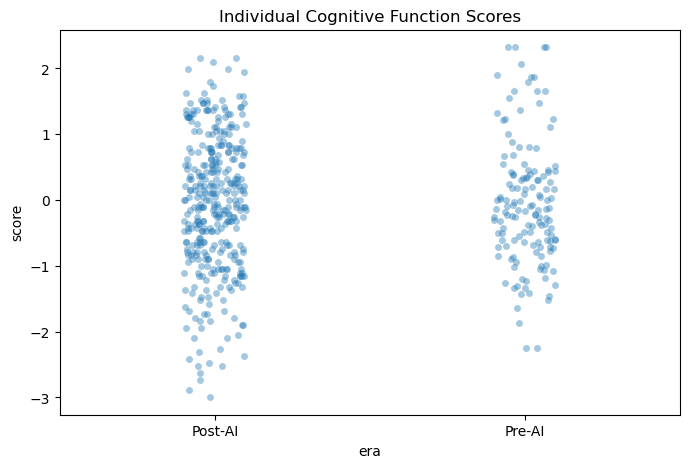

In [16]:
sample_df = df.sample(500)

plt.figure(figsize=(8,5))

sns.stripplot(
    data=sample_df,
    x="era",
    y="score",
    alpha=0.4
)

plt.title("Individual Cognitive Function Scores")
plt.show()


## Normality Assessment (QQ Plots)

This QQ plot compares the distribution of cognitive-function scores to a theoretical normal distribution. Most points closely follow the reference line, suggesting that the data are approximately normally distributed, with only minor deviations in the tails.

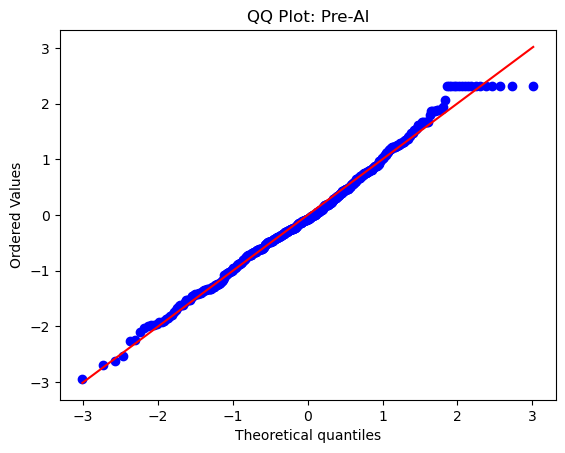

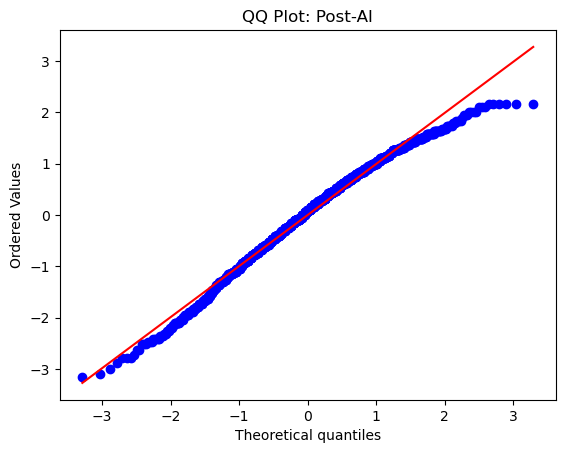

In [17]:
from scipy import stats

stats.probplot(pre_z, dist="norm", plot=plt)
plt.title("QQ Plot: Pre-AI")
plt.show()

stats.probplot(post_z, dist="norm", plot=plt)
plt.title("QQ Plot: Post-AI")
plt.show()



## Statistical Analysis

We run three complementary tests. First, a **Welch's independent samples t-test** tests whether the mean standardized scores differ significantly between cohorts. We use Welch's version (equal_var=False) because the groups have different sample sizes (534 vs. 1,373) and we cannot assume equal population variances across two different instruments. Second, **Cohen's d** quantifies the effect size — a t-test alone only tells us whether a difference exists, not how large it is. Third, a **Mann-Whitney U test** serves as a non-parametric backup that makes no assumption about distributional shape; agreement between both tests strengthens confidence in the result.

In [18]:
# Welch's t-test
t_stat, p_ttest = ttest_ind(pre_z, post_z, equal_var=False)

# Cohen's d (effect size)
pooled_sd = np.sqrt((pre_z.std()**2 + post_z.std()**2) / 2)
cohens_d  = (post_z.mean() - pre_z.mean()) / pooled_sd

# Magnitude label
if   abs(cohens_d) >= 0.8: magnitude = 'large'
elif abs(cohens_d) >= 0.5: magnitude = 'medium'
elif abs(cohens_d) >= 0.2: magnitude = 'small'
else:                       magnitude = 'negligible'

# Mann-Whitney U test (non-parametric backup)
u_stat, p_mw = mannwhitneyu(pre_z, post_z, alternative='two-sided')

print('─' * 50)
print('Welch\'s t-test:')
print(f'  t = {t_stat:.4f},  p = {p_ttest:.4f}')
print()
print('Effect size:')
print(f"  Cohen's d = {cohens_d:.4f}  ({magnitude})")
print()
print('Mann-Whitney U test:')
print(f'  U = {u_stat:.2f},  p = {p_mw:.4f}')
print('─' * 50)


──────────────────────────────────────────────────
Welch's t-test:
  t = -0.0000,  p = 1.0000

Effect size:
  Cohen's d = 0.0000  (negligible)

Mann-Whitney U test:
  U = 355723.00,  p = 0.3141
──────────────────────────────────────────────────


**Interpretation:** Both the Welch's t-test and Mann-Whitney U test indicated that there was no statistically significant difference in standardized cognitive-function scores between the Pre-AI and Post-AI cohorts (p > 0.05). In addition, Cohen's d was approximately zero, indicating a negligible effect size. Together, these results suggest that cognitive-function scores were largely similar across the two groups, providing no evidence of a meaningful difference associated with the timing of data collection relative to the widespread adoption of generative AI.

## Conclusion and Discussion

Based on the findings of the statistical analysis, we did not find a statistically significant difference in standardized cognitive-function scores between college students surveyed before and after the widespread adoption of generative AI. Although the post-AI cohort showed a slight higher median standardized score, the difference was not statistically significant according to the Mann-Whiney U test (p=0.314)
These findings do not support our original hypothesis that students surveyed after the widespread adoption of generative AI would report lower cognitive-function scores. While previous research has suggested that AI-assisted task completion may reduce cognitive engagement and increase cognitive offloading, our results indicate that such effects may not be reflected in broader self-reported cognitive-function measures at the population level. Overall, the results suggest that cognitive-function measures were largely similar across the two cohorts.

**Limitations:**

Regardless of our findings, it is hard to conclude that the widespread use of AI directly influences cognitive functioning. Because neither dataset measured individual AI usage, we cannot attribute any observed similarities or differences to generative AI itself. Furthermore, correlation does not imply causation, and many factors other than AI may contribute to cognitive-function measures.
A major limitation of this study is that the two datasets were collected from different populations and used different survey instruments. Our datasets have way too many variables, different countries, languages, schooling systems, academic norms, etc. Additionally,  both datasets measured aspects of cognitive functioning, they did not assess identical constructs. Our project assumes that the popularization of AI is prevalent among college students. These differences introduce potential confounding variables that make direct comparisons challenging. Finally, many societal and educational changes occurred between 2018 and 2025, making it difficult to isolate the potential influence to only generative AI and away from other factors. In addition, both datasets relied on self-reported measures rather than direct behavioral assessments of executive function.


**Future Direction:**

There are still ongoing debates about whether generative AI has a positive correlation with reduced executive function. Some studies suggest that if used correctly, AI can lighten workloads and act as an educator. To better understand these effects, future studies could examine the context in which AI is used, rather than only focusing on cognitive tests. One type of study that would improve our findings is a direct AI usage measurement, combined with a longitudinal study, measuring students across a set number of years. This type of study could help determine whether frequent AI use leads to changes in executive function over time or whether certain ways of using AI actually support cognitive development and learning outcomes. Together, these approaches would provide a more direct test of how generative AI influences cognitive functioning and learning over time.
